In [1]:
import sys
sys.path.append("../..")

In [2]:
from grins.config import SVI_DATA_DIR
from PIL import Image
from transformers import Sam3Processor, Sam3Model
import torch
from PIL import Image
import requests
import numpy as np
import matplotlib
import matplotlib.patches as patches
import matplotlib.pyplot as plt
BARI_ITALY_DIR = SVI_DATA_DIR / "Bari_Italy"
IMAGES_DIR = BARI_ITALY_DIR / "images"

2025-12-13 16:52:40.097 | INFO     | grins.config:<module>:11 - PROJ_ROOT path is: /home/nicola/Development/GRINS
/home/nicola/Development/GRINS/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


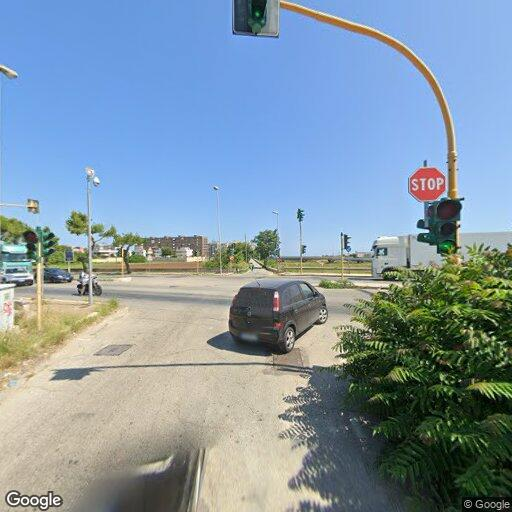

In [3]:
# Get the first image from IMAGES_DIR / "0"
first_image_path = IMAGES_DIR / "0" / sorted((IMAGES_DIR / "0").glob("*.jpg"))[3].name
image = Image.open(first_image_path)
image

In [4]:
device = "cuda:1"

model = Sam3Model.from_pretrained("facebook/sam3").to(device)
processor = Sam3Processor.from_pretrained("facebook/sam3")

Loading weights: 100%|██████████| 1468/1468 [00:01<00:00, 1253.51it/s, Materializing param=vision_encoder.neck.fpn_layers.3.proj2.weight]                       


In [5]:
# Segment using text prompt
objects = ["car", "truck", "bus", "van"]
all_results = {}
for obj in objects + [f"{obj} shadow" for obj in objects]:
    inputs = processor(images=image, text=[obj], return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    result = processor.post_process_instance_segmentation(
        outputs,
        threshold=0.5,
        mask_threshold=0.5,
        target_sizes=inputs.get("original_sizes").tolist()
    )[0]
    # Store all results for this object type (masks, scores, boxes)
    all_results[obj] = {
        "masks": result["masks"],
        "scores": result["scores"],
        "boxes": result["boxes"]
    }

print(f"Collected results for: {list(all_results.keys())}")

Collected results for: ['car', 'truck', 'bus', 'van', 'car shadow', 'truck shadow', 'bus shadow', 'van shadow']


In [6]:
def overlay_masks(image, masks):
    image = image.convert("RGBA")
    masks = 255 * masks.cpu().numpy().astype(np.uint8)
    
    n_masks = masks.shape[0]
    cmap = matplotlib.colormaps.get_cmap("rainbow").resampled(n_masks)
    colors = [
        tuple(int(c * 255) for c in cmap(i)[:3])
        for i in range(n_masks)
    ]

    for mask, color in zip(masks, colors):
        mask = Image.fromarray(mask)
        overlay = Image.new("RGBA", image.size, color + (0,))
        alpha = mask.point(lambda v: int(v * 0.5))
        overlay.putalpha(alpha)
        image = Image.alpha_composite(image, overlay)
    return image

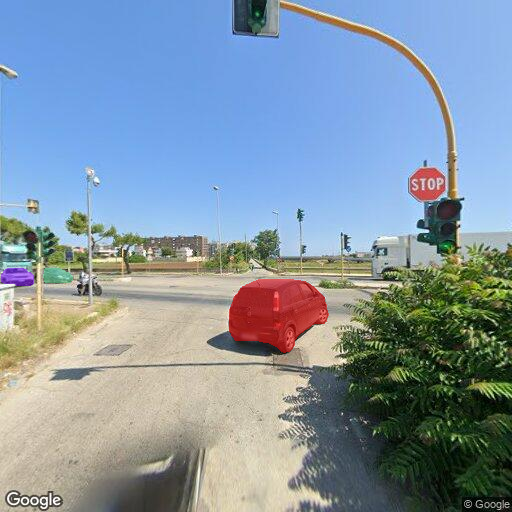

In [7]:
# Display detected car masks
overlay_masks(image, all_results["car"]["masks"])

In [8]:
from simple_lama_inpainting import SimpleLama
import cv2

# Load LAMA inpainting model
simple_lama = SimpleLama()

In [9]:
def mask_tensor_to_pil(mask_tensor):
    """Convert a single mask tensor to a PIL Image (white = inpaint area)."""
    mask_np = mask_tensor.cpu().numpy().astype(np.uint8) * 255
    return Image.fromarray(mask_np, mode="L")

def get_mask_area(mask_tensor):
    """Get the number of pixels in the mask."""
    return mask_tensor.sum().item()

def get_mask_bbox_area(mask_tensor):
    """Get the bounding box area of the mask."""
    mask_np = mask_tensor.cpu().numpy()
    rows = np.any(mask_np, axis=1)
    cols = np.any(mask_np, axis=0)
    if not rows.any() or not cols.any():
        return 0
    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]
    return (rmax - rmin) * (cmax - cmin)

def perimeter_based_dilation(mask_pil):
    mask = np.array(mask_pil)
    mask_binary = (mask > 127).astype(np.uint8)
    contours, _ = cv2.findContours(mask_binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    total_perimeter = sum(cv2.arcLength(cnt, True) for cnt in contours)
    if total_perimeter < 200:
        kernel_size = 5
        iterations = 3
    elif total_perimeter < 400:
        kernel_size = 7
        iterations = 3
    elif total_perimeter < 700:
        kernel_size = 9
        iterations = 3
    elif total_perimeter < 1200:
        kernel_size = 11
        iterations = 3
    else:
        kernel_size = 13
        iterations = 3
    kernel = np.ones((kernel_size, kernel_size), np.uint8)
    dilated = cv2.dilate(mask_binary * 255, kernel, iterations=iterations)
    return Image.fromarray(dilated, mode="L")

Found 3 cars to remove

--- Removing car 1/3 ---
Mask area: 503 pixels
Using LAMA inpainting with perimeter-based dilated mask


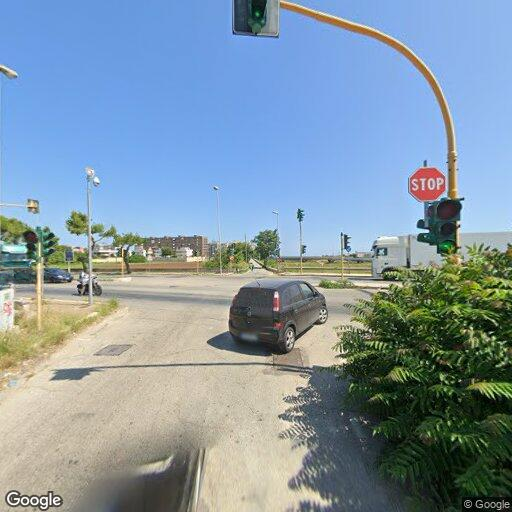

Car 1 removed

--- Removing car 2/3 ---
Mask area: 384 pixels
Using LAMA inpainting with perimeter-based dilated mask


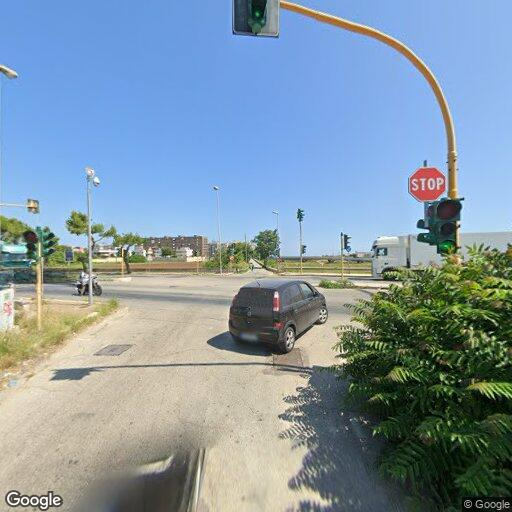

Car 2 removed

--- Removing car 3/3 ---
Mask area: 5337 pixels
Using LAMA inpainting with perimeter-based dilated mask


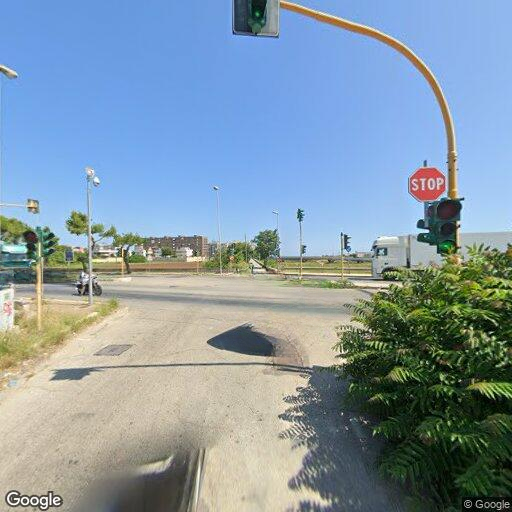

Car 3 removed

--- Final result ---


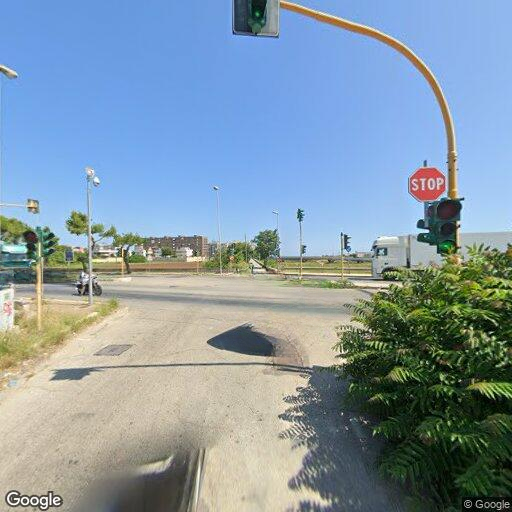

In [10]:
# Iteratively remove cars one by one using LAMA inpainting with perimeter-based dilated masks
current_image = image.copy()
masks = all_results["car"]["masks"]
n_cars = len(masks)

print(f"Found {n_cars} cars to remove")

intermediate_results = [("original", -1, image.copy())]

for i in range(n_cars):
    print(f"\n--- Removing car {i+1}/{n_cars} ---")
    
    # Convert mask tensor to PIL Image
    mask_pil = mask_tensor_to_pil(masks[i])
    
    # Check mask size
    mask_area = get_mask_area(masks[i])
    print(f"Mask area: {mask_area} pixels")
    
    # Store mask visualization
    intermediate_results.append(("mask", i, mask_pil))
    
    # Dilate mask using perimeter-based algorithm and use LAMA
    dilated_mask_pil = perimeter_based_dilation(mask_pil)
    print("Using LAMA inpainting with perimeter-based dilated mask")
    edited_image = simple_lama(current_image, dilated_mask_pil)
    
    intermediate_results.append(("result", i, edited_image))
    
    # Display the result
    display(edited_image)
    print(f"Car {i+1} removed")
    
    # Update current image for next iteration
    current_image = edited_image

print("\n--- Final result ---")
display(current_image)

NameError: name 'results' is not defined

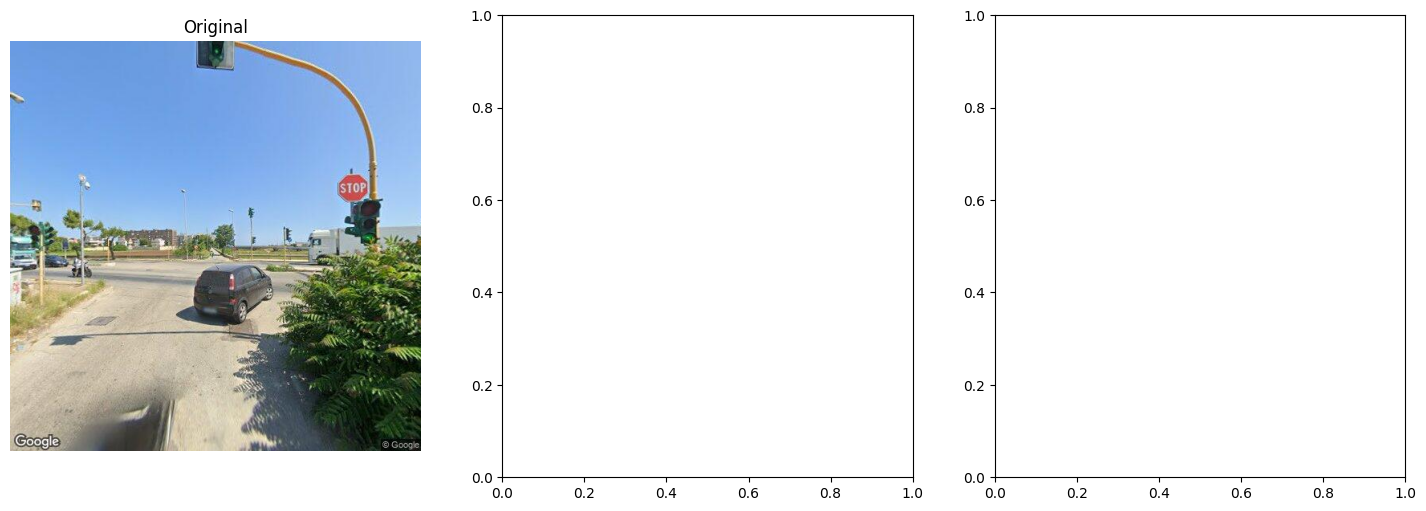

In [11]:
# Display comparison: original vs final
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(image)
axes[0].set_title("Original")
axes[0].axis('off')

# Combined mask
combined_mask = torch.any(results["masks"], dim=0)
axes[1].imshow(overlay_masks(image, results["masks"]))
axes[1].set_title(f"Detected Cars ({n_cars})")
axes[1].axis('off')

axes[2].imshow(current_image)
axes[2].set_title("Cars Removed")
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
def compute_iou(mask1, mask2):
    # mask1, mask2: numpy arrays of shape (H, W), binary
    intersection = np.logical_and(mask1, mask2).sum()
    union = np.logical_or(mask1, mask2).sum()
    if union == 0:
        return 0.0
    return intersection / union

def masks_touch(mask1, mask2):
    # Returns True if masks touch (dilated overlap)
    kernel = np.ones((3, 3), np.uint8)
    mask1_dil = cv2.dilate(mask1.astype(np.uint8), kernel, iterations=1)
    return np.any(np.logical_and(mask1_dil, mask2))

def join_object_and_shadow_masks(all_results):
    obj_types = ["car", "truck", "bus", "van"]
    obj_masks = {}
    for obj in obj_types:
        obj_entry = all_results.get(obj)
        shadow_entry = all_results.get(f"{obj} shadow")
        if obj_entry is None or len(obj_entry["masks"]) == 0:
            continue
        obj_masks[obj] = []
        obj_masks_list = obj_entry["masks"]
        if shadow_entry is not None and len(shadow_entry["masks"]) > 0:
            shadow_masks_list = shadow_entry["masks"]
        else:
            shadow_masks_list = []
        for i, obj_mask in enumerate(obj_masks_list):
            obj_mask_np = obj_mask.cpu().numpy().astype(np.uint8)
            best_combined = obj_mask_np
            for shadow_mask in shadow_masks_list:
                shadow_mask_np = shadow_mask.cpu().numpy().astype(np.uint8)
                iou = compute_iou(obj_mask_np, shadow_mask_np)
                touch = masks_touch(obj_mask_np, shadow_mask_np)
                if iou > 0.05 or touch:
                    best_combined = np.logical_or(obj_mask_np, shadow_mask_np).astype(np.uint8)
                    break  # Only combine with the first matching shadow
            obj_masks[obj].append(torch.from_numpy(best_combined))
    return obj_masks

object_shadow_masks = join_object_and_shadow_masks(all_results)

In [ ]:
object

In [ ]:
# Replace the inpainting loop (Cell 12) with the following:
current_image = image.copy()
total_masks = sum(len(masks) for masks in object_shadow_masks.values())
print(f"Found {total_masks} object+shadow masks to remove")

for obj, masks in object_shadow_masks.items():
    for i, mask in enumerate(masks):
        print(f"\n--- Removing {obj} + shadow instance {i+1}/{len(masks)} ---")
        mask_pil = mask_tensor_to_pil(mask)
        dilated_mask_pil = perimeter_based_dilation(mask_pil)
        print(f"Using LAMA inpainting for {obj} + shadow instance {i+1}")
        edited_image = simple_lama(current_image, dilated_mask_pil)
        display(edited_image)
        current_image = edited_image

print("\n--- Final result ---")
display(current_image)